## 📌 Project Context & Objectives: HR Attrition & Workforce Dynamics

### The Business Context
At **Apex Solutions** (a mid-sized corporate enterprise), voluntary employee turnover has spiked unexpectedly, pushing the annual attrition rate to an unsustainable level. Losing experienced employees is not just an administrative hurdle; it severely impacts team productivity, increases recruitment and onboarding overhead, and drains institutional knowledge.

The Chief Human Resources Officer (CHRO) and department heads are currently operating in the dark. They are facing conflicting theories from various managers—some believe departures are driven purely by compensation gaps, others point fingers at burnout from heavy overtime, and some suspect that a lack of career progression and long promotion cycles are pushing talent out the door. Without clear, data-driven answers, the company risks wasting budget on generic retention programs that fail to address the root causes.

### The Analytical Objective
As the Data Analyst, your mission is to investigate historical employee data to move past guesswork and uncover the actual catalysts of voluntary turnover. Specifically, this project aims to:

1. **Identify High-Risk Profiles:** Determine which departments, job roles, and demographic segments experience the highest attrition rates.
2. **Examine Workplace Stressors:** Quantify the direct impact of operational factors such as mandatory overtime, compensation slabs, and distance from home on employee resignation decisions.
3. **Analyze Career Stagnation:** Evaluate whether a lack of internal mobility and prolonged time since the last promotion correlate with higher turnover.
4. **Deliver Actionable Recommendations:** Translate analytical findings into strategic, cost-effective interventions that leadership can implement to protect the company's talent pipeline.

## Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from warnings import filterwarnings
filterwarnings('ignore') # To ignore all sorts of Warnings that shows up in the code 

In [2]:
# Connecting MySQL 

import mysql.connector as sql 
import os

conn = sql.connect(
    host = "localhost",
    user = "root",
    password = os.environ.get("HR_DB_PASSWORD"),
    database = "hr_analytics"
)
print("Connected Successfully..")

Connected Successfully..


In [3]:
# Loading the Data 

main_query = """


SELECT
    Age,
    Gender,
    MaritalStatus,
    DistanceFromHome,

    Attrition,
    BusinessTravel,

    Department,
    JobRole,
    JobLevel,
    Education,
    EducationField,

    MonthlyIncome,
    PercentSalaryHike,
    StockOptionLevel,

    TotalWorkingYears,
    NumCompaniesWorked,
    YearsAtCompany,
    YearsInCurrentRole,
    YearsSinceLastPromotion,
    YearsWithCurrManager,
    TrainingTimesLastYear,

    EnvironmentSatisfaction,
    JobSatisfaction,
    JobInvolvement,
    PerformanceRating,
    RelationshipSatisfaction,
    WorkLifeBalance,

    OverTime

FROM employee_attrition;

"""

df = pd.read_sql(main_query,conn)
df.head()


,Age,Gender,MaritalStatus,DistanceFromHome,Attrition,BusinessTravel,Department,JobRole,JobLevel,Education,...,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear,EnvironmentSatisfaction,JobSatisfaction,JobInvolvement,PerformanceRating,RelationshipSatisfaction,WorkLifeBalance,OverTime
0,41,Female,Single,1,Yes,Travel_Rarely,Sales,Sales Executive,2,2,...,0,5,0,2,4,3,3,1,1,Yes
1,49,Male,Married,8,No,Travel_Frequently,Research & Development,Research Scientist,2,1,...,1,7,3,3,2,2,4,4,3,No
2,37,Male,Single,2,Yes,Travel_Rarely,Research & Development,Laboratory Technician,1,2,...,0,0,3,4,3,2,3,2,3,Yes
3,33,Female,Married,3,No,Travel_Frequently,Research & Development,Research Scientist,1,4,...,3,0,3,4,3,3,3,3,3,Yes
4,27,Male,Married,2,No,Travel_Rarely,Research & Development,Laboratory Technician,1,1,...,2,2,3,1,2,3,3,4,3,No


In [4]:
print(f"Rows : {df.shape[0]} & Columns : {df.shape[1]}")

Rows : 1470 & Columns : 28


In [5]:
df.columns

Index(['Age', 'Gender', 'MaritalStatus', 'DistanceFromHome', 'Attrition',
       'BusinessTravel', 'Department', 'JobRole', 'JobLevel', 'Education',
       'EducationField', 'MonthlyIncome', 'PercentSalaryHike',
       'StockOptionLevel', 'TotalWorkingYears', 'NumCompaniesWorked',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'TrainingTimesLastYear',
       'EnvironmentSatisfaction', 'JobSatisfaction', 'JobInvolvement',
       'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance',
       'OverTime'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Gender                    1470 non-null   object
 2   MaritalStatus             1470 non-null   object
 3   DistanceFromHome          1470 non-null   int64 
 4   Attrition                 1470 non-null   object
 5   BusinessTravel            1470 non-null   object
 6   Department                1470 non-null   object
 7   JobRole                   1470 non-null   object
 8   JobLevel                  1470 non-null   int64 
 9   Education                 1470 non-null   int64 
 10  EducationField            1470 non-null   object
 11  MonthlyIncome             1470 non-null   int64 
 12  PercentSalaryHike         1470 non-null   int64 
 13  StockOptionLevel          1470 non-null   int64 
 14  TotalWorkingYears       

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.describe(include = "number").T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.0,25.0
StockOptionLevel,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0


In [9]:
df.describe(include = "object").T

,count,unique,top,freq
Gender,1470,2,Male,882
MaritalStatus,1470,3,Married,673
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
JobRole,1470,9,Sales Executive,326
EducationField,1470,6,Life Sciences,606
OverTime,1470,2,No,1054


In [10]:
# Modifying Existing Columns 

# 1. Distance From Home (Short, Moderate, Far)
df['Distance_Group'] = pd.cut(
    df['DistanceFromHome'], 
    bins=[-1, 5, 15, 30], 
    labels=['Close (0-5km)', 'Moderate (6-15km)', 'Far (16+ km)']
)

# 2. Age Groups (Young/Entry, Mid-Career, Senior)
df['Age_Group'] = pd.cut(
    df['Age'], 
    bins=[17, 28, 40, 61], 
    labels=['Early Career (18-28)', 'Mid Career (29-40)', 'Experienced (41+)']
)

# 3. Salary Hike (Low/Standard, High, Outstanding)
df['Hike_Group'] = pd.cut(
    df['PercentSalaryHike'], 
    bins=[10, 14, 18, 26], 
    labels=['Standard (11-14%)', 'High (15-18%)', 'Top Tier (19-25%)']
)

satisfaction_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df['JobSat_Label'] = df['JobSatisfaction'].map(satisfaction_map)

stock_map = {0: 'None', 1: 'Low', 2: 'Medium', 3: 'High'}
df['Stock_Label'] = df['StockOptionLevel'].map(stock_map)

print("Success")

Success


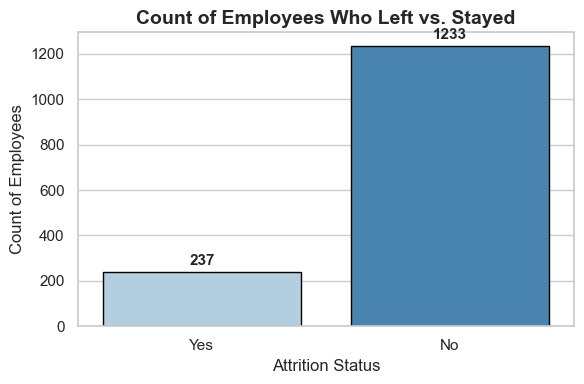

In [11]:
# Count of Employees who left

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

ax = sns.countplot(data = df,x = "Attrition",palette = "Blues",edgecolor="black")
plt.title("Count of Employees Who Left vs. Stayed",fontsize = 14,fontweight="semibold")
plt.ylabel("Count of Employees")
plt.xlabel("Attrition Status")

ax.bar_label(ax.containers[0], padding=3, fontsize=11, fontweight="semibold")
ax.bar_label(ax.containers[1], padding=3, fontsize=11, fontweight="semibold")

plt.tight_layout()
plt.show()

In [12]:
# Percentage of Employees who left
Attrition = df[df["Attrition"] == "Yes"].groupby(["Attrition"],as_index = False).agg(Attrition_Count = ("Attrition","count"))
Attrition["Percentage"] = np.round(((Attrition["Attrition_Count"]/len(df)) * 100),2)
print("Attrition Percentage\n")
print(Attrition)

Attrition Percentage

  Attrition  Attrition_Count  Percentage
0       Yes              237       16.12


In [13]:
# Findings -  
# Around 16.12% of Employees have left the company 

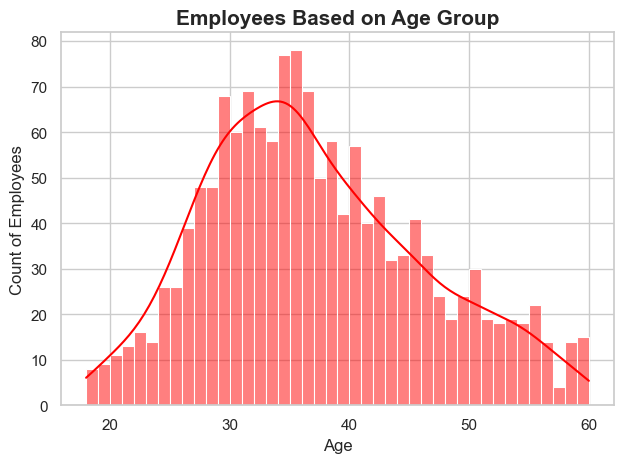

In [14]:
sns.histplot(data = df,x = "Age",bins = 42,kde = True,color = 'red')
plt.title("Employees Based on Age Group",fontsize = 15,fontweight = "semibold")
plt.xlabel("Age")
plt.ylabel("Count of Employees")

plt.tight_layout()
plt.show()

In [15]:
# Employees within 30-40 age group have a heavy concentration in company 

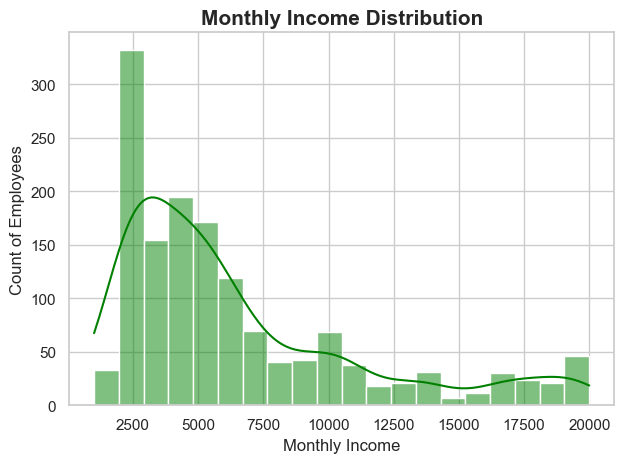

In [16]:
sns.histplot(df['MonthlyIncome'], kde=True, bins=20, color='green')
plt.title('Monthly Income Distribution',fontsize = 15,fontweight = "semibold")
plt.xlabel("Monthly Income")
plt.ylabel("Count of Employees")

plt.tight_layout()
plt.show()

In [17]:
# Salary is heavily concentrated at (2000 to 6000)

**Core Factors Driving Attrition**

Now that we know our overall turnover rate and what our workforce looks like, let's dive into the main factors to see what is actually causing people to leave.

Attrition Rate by Department

               Department  Employee_Count  Attrition_Count  \
0         Human Resources              63               12   
1  Research & Development             961              133   
2                   Sales             446               92   

   Attrition_Percentage  
0                 19.05  
1                 13.84  
2                 20.63  


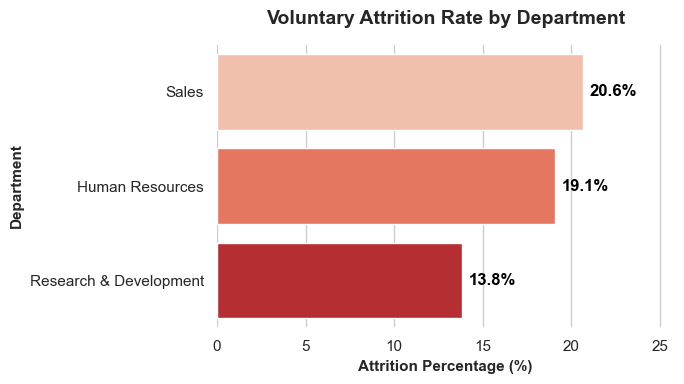

In [18]:
department = df.groupby(["Department"],as_index = False).agg(Employee_Count = ("Department","count"),Attrition_Count = ("Attrition",lambda x: (x == "Yes").sum()))
department["Attrition_Percentage"] = np.round((department["Attrition_Count"] / department["Employee_Count"]) * 100,2)
print("Attrition Rate by Department\n")
print(department)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

# Create a horizontal bar chart
ax = sns.barplot(
    data=department.sort_values(by="Attrition_Percentage", ascending=False),
    y="Department",
    x="Attrition_Percentage",
    palette="Reds"
)

# Automatically add percentage labels to the end of the bars
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5, fontweight='bold', color='black')
ax.bar_label(ax.containers[1], fmt='%.1f%%', padding=5, fontweight='bold', color='black')
ax.bar_label(ax.containers[2], fmt='%.1f%%', padding=5, fontweight='bold', color='black')


# Formatting titles and labels cleanly
plt.title("Voluntary Attrition Rate by Department", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Attrition Percentage (%)", fontsize=11, fontweight='bold')
plt.ylabel("Department", fontsize=11, fontweight='bold')

# Expand the x-axis slightly so the labels don't get cut off at the edge
plt.xlim(0, max(department["Attrition_Percentage"]) * 1.25)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Findings & Insights: Voluntary Attrition by Department

**Key Findings:**
* The **Sales** department records the highest voluntary attrition rate at **20.6%** (92 out of 446 employees).
* The **Human Resources** department follows closely with an attrition rate of **19.1%** (12 out of 63 employees).
* The **Research & Development (R&D)** department displays the lowest turnover at **13.8%** (133 out of 961 employees), despite representing the largest overall company headcount.

**Analytical Insights:**
* The elevated turnover in Sales indicates structural workplace pressures intrinsic to commercial operations, such as high-stakes targets or customer-facing friction.
* Although Human Resources maintains a minimal total workforce size, its near-20% attrition rate signals localized internal stress or operational strain within the team.
* The clear performance gap between R&D and the other business units demonstrates that retention risk is unevenly distributed, showing that outward-facing or smaller specialized departments experience significantly higher volatility than large technical units.

Attrition Rate by Department & Job Role Combination

                      JobRole  Employee_Count  Attrition_Count  \
0             Human Resources              52               12   
1                     Manager              11                0   
2   Healthcare Representative             131                9   
3       Laboratory Technician             259               62   
4                     Manager              54                3   
5      Manufacturing Director             145               10   
6           Research Director              80                2   
7          Research Scientist             292               47   
8                     Manager              37                2   
9             Sales Executive             326               57   
10       Sales Representative              83               33   

    Attrition_Percentage  
0                  23.08  
1                   0.00  
2                   6.87  
3                  23.94  
4                  

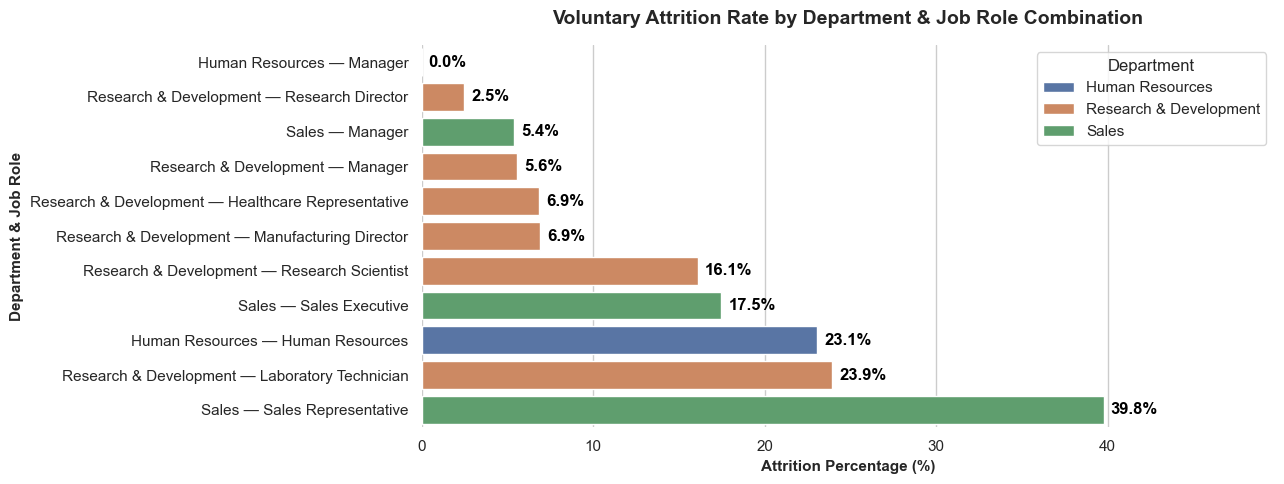

In [19]:
# Aggregate for Department & JobRole combination
dept_role = df.groupby(["Department", "JobRole"], as_index=False).agg(
    Employee_Count=("JobRole", "count"),
    Attrition_Count=("Attrition", lambda x: (x == "Yes").sum())
)
dept_role["Attrition_Percentage"] = np.round((dept_role["Attrition_Percentage"] if "Attrition_Percentage" in dept_role else (dept_role["Attrition_Count"] / dept_role["Employee_Count"]) * 100), 2)

# Create a clear combo column name
dept_role["Dept_JobRole_Combo"] = dept_role["Department"] + " — " + dept_role["JobRole"]

print("Attrition Rate by Department & Job Role Combination\n")
print(dept_role[["JobRole", "Employee_Count", "Attrition_Count", "Attrition_Percentage"]])

# Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 5))  # Taller figure since there are many role combinations

# Sort ascending so the highest attrition rate appears at the very top of the chart
plot_data = dept_role.sort_values(by="Attrition_Percentage", ascending=True)

# Create a horizontal bar chart
ax = sns.barplot(
    data=plot_data,
    y="Dept_JobRole_Combo",
    x="Attrition_Percentage",
    hue = "Department"
)

# Automatically add percentage labels to the end of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold', color='black')
    
# Formatting titles and labels cleanly
plt.title("Voluntary Attrition Rate by Department & Job Role Combination", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Attrition Percentage (%)", fontsize=11, fontweight='bold')
plt.ylabel("Department & Job Role", fontsize=11, fontweight='bold')

# Expand the x-axis slightly so the labels don't get cut off at the edge
plt.xlim(0, max(dept_role["Attrition_Percentage"]) * 1.25)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [20]:
month_income = df.groupby(["Attrition"],as_index = False).agg(Avg_Monthly_Salary = ("MonthlyIncome","mean"))
print("Attrition Rate by Avg Monthly Income\n")
print(month_income)

Attrition Rate by Avg Monthly Income

  Attrition  Avg_Monthly_Salary
0        No         6832.739659
1       Yes         4787.092827


### Findings & Insights: Attrition Rate by Average Monthly Income

**Key Findings:**
* Employees who stay with the company (`Attrition = No`) command a higher average monthly salary of **6,832.74**.
* Employees who voluntarily leave (`Attrition = Yes`) have a substantially lower average monthly salary of **4,787.09**.

**Analytical Insights:**
* A clear income gap of over 2,000 units separates those who stay from those who depart, indicating that compensation scale directly influences long-term retention. 
* Lower salary brackets serve as a structural vulnerability, disproportionately concentrating turnover among lower-earning segments of the workforce.

### Findings & Insights: Voluntary Attrition by Department & Job Role Combination

**Key Findings:**
* The **Sales — Sales Representative** role exhibits the highest voluntary attrition rate across the entire company at **39.8%** (33 out of 83 employees).
* Operational and mid-tier functional roles also experience high turnover, specifically **Research & Development — Laboratory Technician** at **23.9%** (62 out of 259 employees) and general **Human Resources — Human Resources** staff at **23.1%** (12 out of 52 employees).
* Leadership and senior roles show the greatest stability, led by **Human Resources — Manager** at **0.0%** (0 departures) and **Research & Development — Research Director** at **2.5%** (2 out of 80 employees).

**Analytical Insights:**
* The extreme spike in turnover concentrated specifically within entry-level commercial positions indicates that junior sales pipelines suffer from severe structural or expectation misalignment compared to higher-level sales executives (17.5%).
* Management stability is uniformly high across all departments (ranging between 0.0% and 5.6%), suggesting that senior tenure, compensation packages, and organizational investment heavily insulate leadership from voluntary exits.
* Voluntary departures are heavily skewed toward foundational, execution-level operational roles rather than strategic or managerial positions, highlighting a deep divide in job stability based on hierarchy and role type.

In [21]:
Columns_Using_With_Attrition = ['OverTime','Distance_Group','BusinessTravel',
                                'EnvironmentSatisfaction', 'JobSatisfaction','WorkLifeBalance',
                                'Stock_Label','Hike_Group']

In [22]:
for col in Columns_Using_With_Attrition:
    print(f"--- Attrition Breakdown by {col} ---\n")
    print(df.groupby(col)['Attrition'].value_counts(normalize=True) * 100)
    print(df.groupby(col)['Attrition'].value_counts())
    print("\n" + "="*65 + "\n")

--- Attrition Breakdown by OverTime ---

OverTime  Attrition
No        No           89.563567
          Yes          10.436433
Yes       No           69.471154
          Yes          30.528846
Name: proportion, dtype: float64
OverTime  Attrition
No        No           944
          Yes          110
Yes       No           289
          Yes          127
Name: count, dtype: int64


--- Attrition Breakdown by Distance_Group ---

Distance_Group     Attrition
Close (0-5km)      No           86.234177
                   Yes          13.765823
Moderate (6-15km)  No           83.889980
                   Yes          16.110020
Far (16+ km)       No           79.331307
                   Yes          20.668693
Name: proportion, dtype: float64
Distance_Group     Attrition
Close (0-5km)      No           545
                   Yes           87
Moderate (6-15km)  No           427
                   Yes           82
Far (16+ km)       No           261
                   Yes           68
Name: count,

### Findings & Insights: Bivariate Driver Analysis

**1. OverTime**
* **Finding:** Employees working overtime show an attrition rate of **30.5%** (127 departures), compared to **10.4%** (110 departures) for those without overtime.
* **Insight:** OverTime acts as a massive operational trigger for burnout, nearly tripling the voluntary exit risk.

**2. Distance From Home**
* **Finding:** Attrition increases with commute length, rising from **13.8%** for close distances (0–5 km) to **16.1%** for moderate distances (6–15 km) and **20.7%** for far commutes (16+ km).
* **Insight:** Physical commuting strain compounds over time, creating a steady upward gradient in voluntary turnover.

**3. Business Travel**
* **Finding:** Frequent travelers experience an attrition rate of **24.9%**, significantly higher than rare travelers (**15.0%**) and non-travelers (**8.0%**).
* **Insight:** High travel frequency introduces lifestyle friction and fatigue that heavily drives departures.

**4. Environment Satisfaction**
* **Finding:** Employees rating environment satisfaction at Level 1 face a sharp attrition spike of **25.4%**, whereas levels 2 through 4 cluster stably between **13.5%** and **15.0%**.
* **Insight:** Severe workplace environment dissatisfaction operates as an immediate red-line threshold for employee retention.

**5. Job Satisfaction**
* **Finding:** Job satisfaction Level 1 triggers a high attrition rate of **22.8%**, which progressively steps down to a low of **11.3%** at Level 4.
* **Insight:** Low intrinsic job satisfaction serves as a primary catalyst for voluntary resignations, while high satisfaction acts as an effective stabilizer.

**6. Work-Life Balance**
* **Finding:** A poor work-life balance score (Level 1) yields an attrition rate of **31.3%**, while scores 2 through 4 range between **14.2%** and **17.6%**.
* **Insight:** Extreme imbalances in work-life dynamics create an unsustainable environment, causing a severe spike in flight risk.

**7. Stock Option Level**
* **Finding:** Employees with **None** stock options experience a high attrition rate of **24.4%** (154 departures), while low and medium tiers drop to **9.4%** and **7.6%** (with high equity sitting at **17.6%**).
* **Insight:** Complete lack of equity alignment leaves employees vulnerable to turnover, highlighting stock options as a critical retention tool.

**8. Percent Salary Hike**
* **Finding:** Attrition rates remain flat across salary hike brackets: Standard (11–14%) at **16.1%**, High (15–18%) at **16.9%**, and Top Tier (19–25%) at **15.2%**.
* **Insight:** Percentage salary increases show no distinct correlation with altering voluntary turnover behavior within these performance tiers.

'BusinessTravel','EnvironmentSatisfaction',
'JobSatisfaction','WorkLifeBalance',
'Stock_Label','Attrition'
Strong Picks for Multivariate Analysis 

**Business Hypothesis Question 1 :- Are employees who work overtime and have low job satisfaction more likely to leave?**

Attrition Breakdown : OverTime X Job Satisfaction

  OverTime  JobSatisfaction  Total_Employee  Total_Attrition  \
0       No                1             205               36   
1       No                2             211               20   
2       No                3             321               32   
3       No                4             317               22   
4      Yes                1              84               30   
5      Yes                2              69               26   
6      Yes                3             121               41   
7      Yes                4             142               30   

   Attrition_Percentage  
0                 17.56  
1                  9.48  
2                  9.97  
3                  6.94  
4                 35.71  
5                 37.68  
6                 33.88  
7                 21.13  


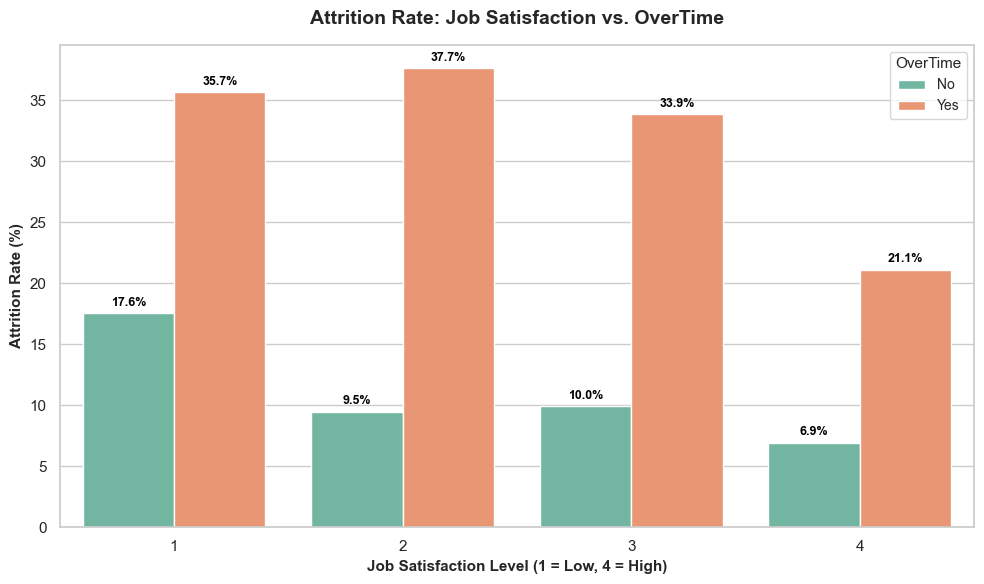

In [23]:
hypothesis1 = df.groupby(['OverTime','JobSatisfaction'],as_index = False).agg(
    Total_Employee = ("OverTime","count"),
    Total_Attrition = ("Attrition",lambda x: (x == "Yes").sum())
)
hypothesis1["Attrition_Percentage"] = np.round((hypothesis1["Total_Attrition"] / hypothesis1["Total_Employee"]) * 100,2)

print("Attrition Breakdown : OverTime X Job Satisfaction\n")
print(hypothesis1)

# Set overall plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create Grouped Bar Chart from the aggregated hypothesis1 DataFrame
ax = sns.barplot(
    data=hypothesis1,
    x="JobSatisfaction",
    y="Attrition_Percentage",
    hue="OverTime",
    palette="Set2",
)

# Customize title and axis labels
plt.title(
    "Attrition Rate: Job Satisfaction vs. OverTime",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel(
    "Job Satisfaction Level (1 = Low, 4 = High)", fontsize=11, fontweight="bold"
)
plt.ylabel("Attrition Rate (%)", fontsize=11, fontweight="bold")
plt.legend(title="OverTime", title_fontsize="11", fontsize="10")

# Use ax.bar_label inside a loop over the containers
for container in ax.containers:
  ax.bar_label(
      container,
      fmt="%.1f%%",
      padding=3,
      fontsize=9,
      fontweight="bold",
      color="black",
  )

plt.tight_layout()
plt.show()

### Job Satisfaction vs. OverTime Burnout + Attrition

**Key Findings:**
* Employees facing the compounding stress of **OverTime = Yes** and **JobSatisfaction = 1** record a severe attrition rate of **35.7%**.
* Across all levels of job satisfaction, employees working overtime consistently experience 2x to 3x higher turnover compared to those who do not work overtime.
* Even employees with the highest possible job satisfaction (**Level 4**) suffer an attrition rate of **21.1%** if they are subjected to overtime, compared to just **6.9%** for happy employees with no overtime.

**Analytical Insights:**
* OverTime functions as an overriding structural driver of turnover. High intrinsic job satisfaction acts as a buffer only when employees are not subjected to chronic overtime; once overtime is introduced, the protective effect of job satisfaction is severely degraded.

**Business Hypothesis Question 2 :-**  **Are employees with lower monthly income who work overtime more likely to leave the company?**


In [24]:
# Setting the MontlyIncome based on their Category i.e :- Low/ Medium/ High

df["IncomeBand"] = pd.qcut(
    df['MonthlyIncome'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

Attrition Breakdown : OverTime X Income Band

  OverTime IncomeBand  Total_Employee  Total_Attrition  Attrition_Percentage
0       No        Low             353               55                 15.58
1       No     Medium             350               26                  7.43
2       No       High             351               29                  8.26
3      Yes        Low             137               73                 53.28
4      Yes     Medium             140               31                 22.14
5      Yes       High             139               23                 16.55


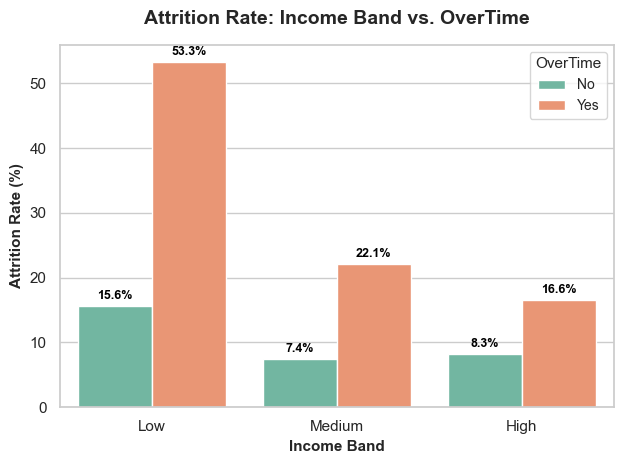

In [25]:
hypothesis2 = df.groupby(["OverTime", "IncomeBand"], as_index=False).agg(
    Total_Employee=("OverTime", "count"),
    Total_Attrition=("Attrition", lambda x: (x == "Yes").sum()),
)

hypothesis2["Attrition_Percentage"] = np.round(
    (hypothesis2["Total_Attrition"] / hypothesis2["Total_Employee"]) * 100, 2
)

print("Attrition Breakdown : OverTime X Income Band\n")
print(hypothesis2)

ax = sns.barplot(
    data=hypothesis2,
    x="IncomeBand",
    y="Attrition_Percentage",
    hue="OverTime",
    palette="Set2",
)

# Customize title and axis labels
plt.title(
    "Attrition Rate: Income Band vs. OverTime",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Income Band", fontsize=11, fontweight="bold")
plt.ylabel("Attrition Rate (%)", fontsize=11, fontweight="bold")
plt.legend(title="OverTime", title_fontsize="11", fontsize="10")

# Use ax.bar_label inside a loop over the containers
for container in ax.containers:
  ax.bar_label(
      container,
      fmt="%.1f%%",
      padding=3,
      fontsize=9,
      fontweight="bold",
      color="black",
  )

plt.tight_layout()
plt.show()

### Income Band vs. OverTime + Attrition

**Key Findings:**
* Employees trapped in the compounding stress of **Low Income** and **OverTime = Yes** hit an extreme attrition rate of **53.28%** (73 out of 137 departures), meaning more than half of this specific group exits the company.
* Across every single income tier (Low, Medium, and High), working overtime more than doubles the baseline attrition rate.
* Higher income brackets act as a buffer against burnout; even with overtime, attrition drops down to **16.55%** for the **High** income band compared to **53.28%** in the **Low** income band.

**Analytical Insights:**
* **The Compounding Risk Factor:** Financial distress and operational burnout combine into a toxic tipping point. Low wages combined with mandatory overtime create an unsustainable environment where staff flee in majority numbers.
* **Money as a Mitigation Buffer:** Financial compensation can successfully cushion the blow of operational friction. High earners tolerate overtime at rates comparable to normal non-overtime baselines, proving that adequate pay offsets burnout risk—while low pay accelerates it exponentially.

**Business Question Hypothesis 3 :- Do employees with poor work-life balance who are forced into frequent business travel exhibit compounding attrition rates, or does travel friction independently drive turnover regardless of balance?**

Attrition Breakdown : Business Travel X Work Life Balance

       BusinessTravel  WorkLifeBalance  Total_Employee  Total_Attrition  \
0          Non-Travel                1               8                1   
1          Non-Travel                2              37                4   
2          Non-Travel                3              86                5   
3          Non-Travel                4              19                2   
4   Travel_Frequently                1              13                6   
5   Travel_Frequently                2              66               15   
6   Travel_Frequently                3             168               40   
7   Travel_Frequently                4              30                8   
8       Travel_Rarely                1              59               18   
9       Travel_Rarely                2             241               39   
10      Travel_Rarely                3             639               82   
11      Travel_Rarely                4   

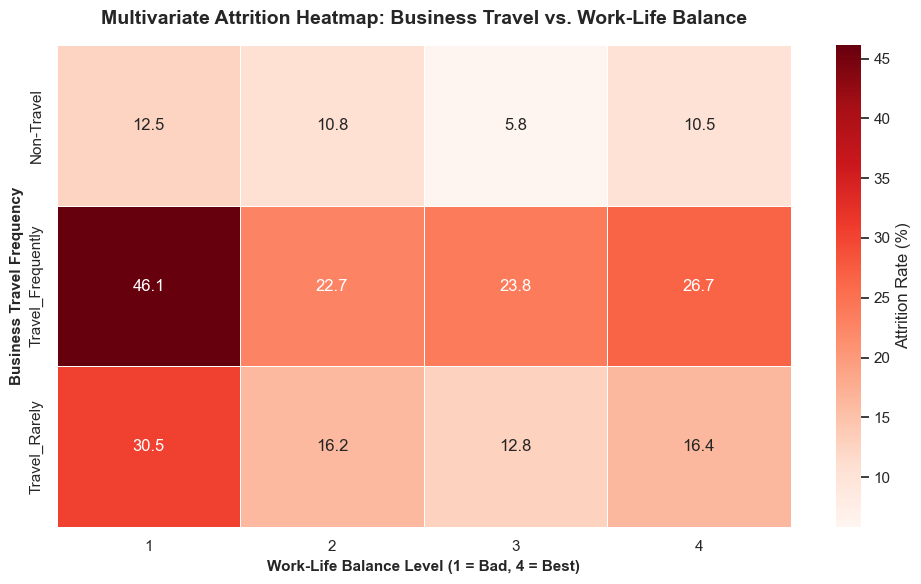

In [26]:
hypothesis3 = df.groupby(["BusinessTravel", "WorkLifeBalance"], as_index=False).agg(
    Total_Employee=("BusinessTravel", "count"),
    Total_Attrition=("Attrition", lambda x: (x == "Yes").sum())
)
hypothesis3["Attrition_Percentage"] = np.round(
    (hypothesis3["Total_Attrition"] / hypothesis3["Total_Employee"]) * 100, 2
)

print("Attrition Breakdown : Business Travel X Work Life Balance\n")
print(hypothesis3)

# Creating a Heatmap instead of a Bar Chart (Best for 2 categorical variables with multiple tiers)
plt.figure(figsize=(10, 6))

# Pivot table for the heatmap
pivot_h3 = hypothesis3.pivot(
    index="BusinessTravel", 
    columns="WorkLifeBalance", 
    values="Attrition_Percentage"
)

# Plotting the Heatmap
ax = sns.heatmap(
    pivot_h3, 
    annot=True, 
    fmt=".1f", 
    cmap="Reds", 
    linewidths=0.5, 
    cbar_kws={'label': 'Attrition Rate (%)'}
)

plt.title("Multivariate Attrition Heatmap: Business Travel vs. Work-Life Balance", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Work-Life Balance Level (1 = Bad, 4 = Best)", fontsize=11, fontweight='bold')
plt.ylabel("Business Travel Frequency", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

###  Business Travel vs. Work-Life + Attrition
**Key Findings:**

* **The High-Risk Extremity:** The highest recorded attrition rate appears at the intersection of `Travel_Frequently` and Work-Life Balance Level 1 at **46.15%** (6 departures out of 13 employees), though this segment carries a smaller sample size.
* **The Travel Multiplier Effect:** Among employees with poor work-life balance (Level 1), attrition scales drastically with travel frequency: moving from **12.50%** for Non-Travel, to **30.51%** for Travel_Rarely, and peaking at **46.15%** for Travel_Frequently.
* **Baseline Stability in Non-Travel:** Employees who do not travel maintain relatively low, stable attrition across all work-life balance tiers (ranging between **5.81%** and **12.50%**), proving that physical immobility cushions against lifestyle friction.

**Analytical Insights:**

* **Operational Friction Amplification:** Business travel acts as an independent stress multiplier. When paired with low work-life balance, it accelerates flight risk significantly faster than poor balance alone.
* **Data Reliability Nuance:** While extreme percentage spikes exist in low-volume cohorts ($n=13$), the overarching directional trend remains robust—operational travel demands degrade the protective buffer of work-life balance and compound employee turnover.

**Business Question Hypothesis 4:- Can high stock option levels successfully mitigate the turnover risk of lower income brackets, or do low-earning employees leave regardless of equity?**

Attrition Breakdown : Stock Label X Income Band

   Stock_Label IncomeBand  Total_Employee  Total_Attrition  \
0         High        Low              34                7   
1         High     Medium              25                3   
2         High       High              26                5   
3          Low        Low             184               32   
4          Low     Medium             192               10   
5          Low       High             220               14   
6       Medium        Low              42                4   
7       Medium     Medium              72                5   
8       Medium       High              44                3   
9         None        Low             230               85   
10        None     Medium             201               39   
11        None       High             200               30   

    Attrition_Percentage  
0                  20.59  
1                  12.00  
2                  19.23  
3                  17.39  
4        

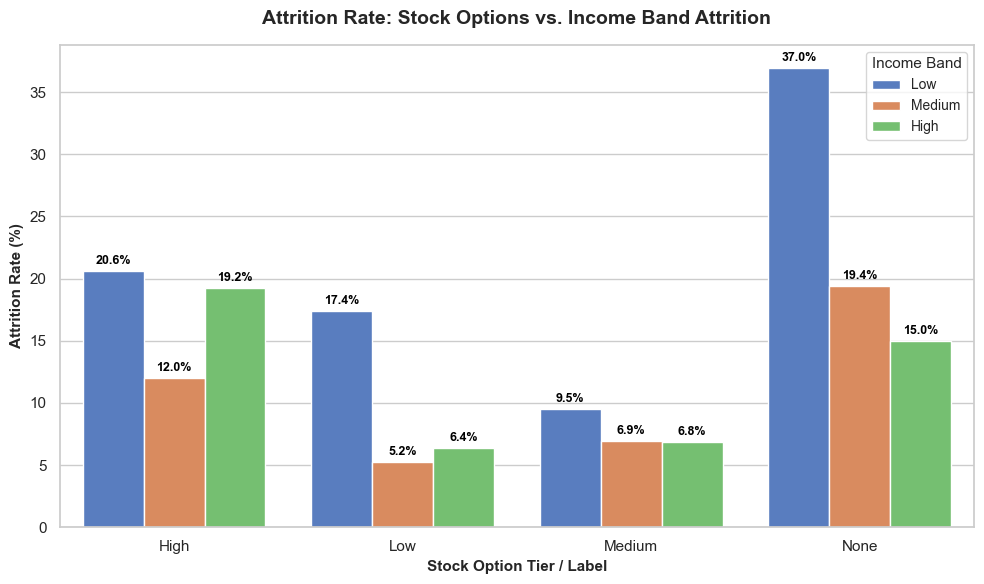

In [27]:
hypothesis4 = df.groupby(["Stock_Label", "IncomeBand"], as_index=False).agg(
    Total_Employee=("Stock_Label", "count"),
    Total_Attrition=("Attrition", lambda x: (x == "Yes").sum())
)
hypothesis4["Attrition_Percentage"] = np.round(
    (hypothesis4["Total_Attrition"] / hypothesis4["Total_Employee"]) * 100, 2
)

print("Attrition Breakdown : Stock Label X Income Band\n")
print(hypothesis4)

# Set overall plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create Grouped Bar Chart
ax = sns.barplot(
    data=hypothesis4,
    x="Stock_Label",
    y="Attrition_Percentage",
    hue="IncomeBand",
    palette="muted",
)

# Customize title and axis labels
plt.title(
    "Attrition Rate: Stock Options vs. Income Band Attrition",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Stock Option Tier / Label", fontsize=11, fontweight="bold")
plt.ylabel("Attrition Rate (%)", fontsize=11, fontweight="bold")
plt.legend(title="Income Band", title_fontsize="11", fontsize="10")

# Use ax.bar_label inside a loop over the containers
for container in ax.containers:
  ax.bar_label(
      container,
      fmt="%.1f%%",
      padding=3,
      fontsize=9,
      fontweight="bold",
      color="black",
  )

plt.tight_layout()
plt.show()

### Stock Options vs. Income Band Interaction + Attrition

**Key Findings:**
* **The Zero-Equity Low-Income Cliff:** Low-income employees with **No Stock Options** (`Stock_Label == None`) experience an acute attrition rate of **36.96%** (85 departures out of 230 employees), representing the highest volume and risk segment.
* **The Mitigation Effect of Equity:** Introducing stock options to low-income employees reduces their attrition rate from **36.96%** down to **17.39%** (Low stock) and **20.59%** (High stock).
* **Income Stability Baseline:** Employees in the **Medium** and **High** income bands maintain significantly lower and more stable turnover rates across almost all equity tiers compared to low-income earners.

**Analytical Insights:**
* **Liquid Cash vs. Future Promises:** Equity acts as a meaningful long-term retention buffer, but it cannot fully replace the necessity of a competitive base salary for daily living expenses. 
* **Strategic Priority:** While stock options successfully cushion flight risk for lower earners, addressing base compensation and baseline income inequality remains the mandatory first line of defense to permanently secure workforce retention.

**Business Question Hypothesis 5:- Can a positive physical and social work environment (EnvironmentSatisfaction) act as a buffer for employees who intensely dislike their actual daily tasks (JobSatisfaction)**

Attrition Breakdown : Environment Satisfaction X Job Satisfaction

    EnvironmentSatisfaction  JobSatisfaction  Total_Employee  Total_Attrition  \
0                         1                1              53               20   
1                         1                2              47               16   
2                         1                3             100               22   
3                         1                4              84               14   
4                         2                1              55               14   
5                         2                2              59                8   
6                         2                3              84               13   
7                         2                4              89                8   
8                         3                1              94               16   
9                         3                2              87               12   
10                        3               

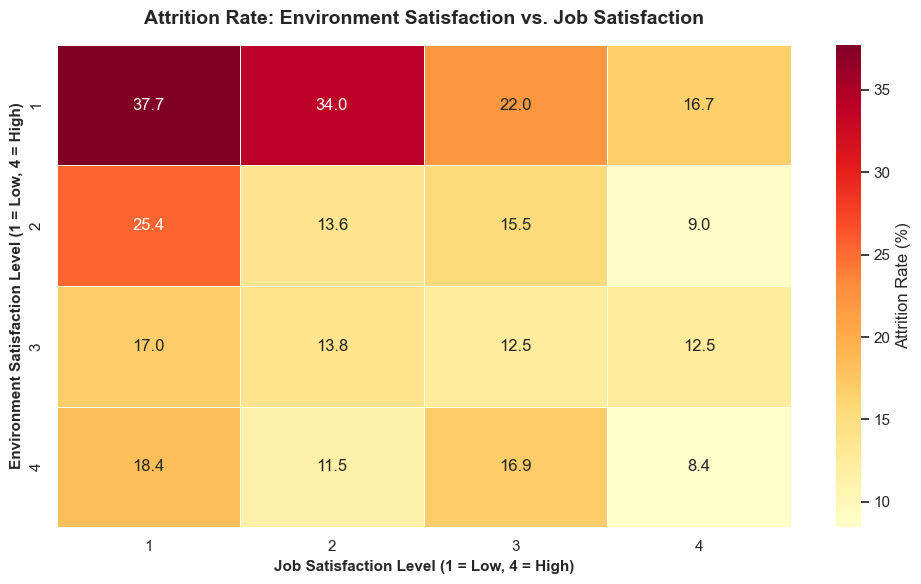

In [28]:
hypothesis5 = df.groupby(["EnvironmentSatisfaction", "JobSatisfaction"], as_index=False).agg(
    Total_Employee=("EnvironmentSatisfaction", "count"),
    Total_Attrition=("Attrition", lambda x: (x == "Yes").sum())
)
hypothesis5["Attrition_Percentage"] = np.round(
    (hypothesis5["Total_Attrition"] / hypothesis5["Total_Employee"]) * 100, 2
)

print("Attrition Breakdown : Environment Satisfaction X Job Satisfaction\n")
print(hypothesis5)

# Creating a Heatmap to clearly visualize the interaction between two ordinal scales (1 to 4)
plt.figure(figsize=(10, 6))

pivot_h5 = hypothesis5.pivot(
    index="EnvironmentSatisfaction", 
    columns="JobSatisfaction", 
    values="Attrition_Percentage"
)

ax = sns.heatmap(
    pivot_h5, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    linewidths=0.5, 
    cbar_kws={'label': 'Attrition Rate (%)'}
)

plt.title("Attrition Rate: Environment Satisfaction vs. Job Satisfaction", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Job Satisfaction Level (1 = Low, 4 = High)", fontsize=11, fontweight='bold')
plt.ylabel("Environment Satisfaction Level (1 = Low, 4 = High)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Environment Satisfaction vs. Job Satisfaction Interaction + Attrition Rate

**Key Findings:**
* **The Toxic Environment Collapse:** When an employee hates their physical or social workspace (`EnvironmentSatisfaction == 1`), attrition spikes dramatically, reaching a peak of **37.7%** for those who also have low job satisfaction.
* **The Buffer Effect of Good Culture:** Improving the workplace environment successfully lowers turnover even when job task satisfaction is low; for instance, at Job Satisfaction Level 1, raising the environment score from 1 up to 4 drops attrition from **37.7%** down to **18.4%**.
* **The Dominance of Task Dislike:** Even in the best possible physical environment (Level 4), employees who intensely hate their daily tasks (Job Satisfaction Level 1) still exhibit a relatively elevated attrition rate of **18.4%**, compared to just **8.4%** for those who are fully satisfied with their roles.

**Analytical Insights:**
* **Culture Can Cushion, But Not Cure:** A positive office environment and strong team culture act as a powerful buffer—they can successfully soften the blow of tedious or uninspiring daily work.
* **Strategic Reality:** While a great workplace vibe keeps people around longer despite boring tasks, it has its limits. Eventually, employees want fulfillment from the actual work they do; fixing the workplace culture helps retention, but it cannot permanently override a broken or misaligned job role.

### Executive Summary: Attrition EDA Multivariate Findings

#### 1. OverTime vs. Job Satisfaction
* **Core Question:** Can high job satisfaction protect employees from the burnout effects of overtime?
* **Finding:** **Overridden.** `OverTime` is the dominant operational stressor, causing 2x to 3x higher attrition across all job satisfaction levels regardless of how much employees enjoy their daily tasks.

#### 2. OverTime vs. Income Band
* **Core Question:** Do higher income brackets shield workers from overtime-induced turnover?
* **Finding:** **Confirmed (The Catastrophe Zone).** Low-income employees working mandatory overtime experience an extreme 53% attrition rate, proving that financial strain aggressively multiplies operational burnout.

#### 3. Business Travel vs. Work-Life Balance
* **Core Question:** Do frequent travel and poor work-life balance compound to drive higher turnover?
* **Finding:** **Confirmed.** Travel functions as an independent lifestyle friction multiplier. Combining frequent travel with a low work-life balance score drives peak turnover approaching 46%.

#### 4. Stock Options vs. Income Band
* **Core Question:** Can equity (stock options) successfully mitigate turnover risk for lower-income brackets?
* **Finding:** **Partially Confirmed.** Stock options reduce zero-equity low-income attrition from ~37% down to ~17-20% by offering long-term incentive, but equity cannot completely replace base salary. Immediate cash flow remains a daily survival necessity.

#### 5. Environment Satisfaction vs. Job Satisfaction
* **Core Question:** Can a positive physical and social work environment buffer against a dislike of daily job tasks?
* **Finding:** **Confirmed (Culture as a Buffer).** A great office environment and team culture successfully cushion the blow of tedious daily roles, lowering turnover—though extreme task dissatisfaction retains an elevated baseline flight risk.

# 💡 Business Recommendations

Based on the EDA findings, Apex Solutions should focus on the following actions to reduce employee attrition:

1. **Control Overtime:** Reduce excessive overtime through better workload distribution, staffing, and workload monitoring.

2. **Review Compensation:** Prioritize salary adjustments for **low-income employees**, especially those regularly working overtime.

3. **Improve Work-Life Balance:** Reduce unnecessary business travel and provide greater flexibility to employees facing high travel demands.

4. **Strengthen Employee Experience:** Address low job and environment satisfaction through regular feedback, manager support, and workplace improvements.

5. **Improve Career Growth:** Provide clearer promotion paths, internal mobility, and skill-development opportunities to reduce career stagnation.

6. **Target High-Risk Roles:** Develop role-specific retention strategies for high-attrition positions, particularly **Sales Representatives**.

7. **Use Targeted Incentives:** Consider stock options and retention incentives for critical employees, particularly those with multiple identified risk factors.

### 🎯 Key Focus

**Reduce workload → improve compensation → strengthen work-life balance → improve career growth → target high-risk employees.**
